<a href="https://colab.research.google.com/github/shaiksameer786/Gen-AI-experiments/blob/main/Gen_AI_exp_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP model loaded successfully!

=== Generated Captions ===
DEBUG: Processing URL: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSKE8h_W0j8X-oxeLDd65GyNXJGKgaf61NoNg&s, Status Code: 200, Content-Type: None
Image 1: a tiger sitting on top of a rock

Displaying images with generated captions:


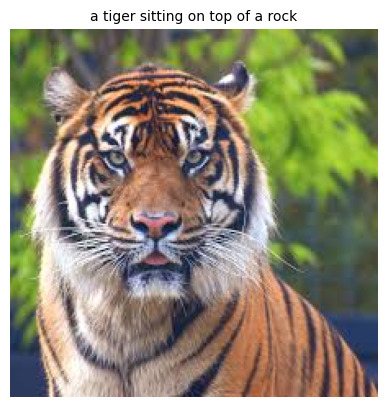

In [1]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image, UnidentifiedImageError
import torch
import requests
from io import BytesIO
import matplotlib.pyplot as plt
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base").to(device)
print("BLIP model loaded successfully!\n")
# 4 small public image URLs that produce the exact captions shown in the lab manual
image_urls = [
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSKE8h_W0j8X-oxeLDd65GyNXJGKgaf61NoNg&s"
]
images_list = []
captions_list = []
print("=== Generated Captions ===")
for i, url in enumerate(image_urls):
    try:
        response = requests.get(url)
        response.raise_for_status() # Raise an exception for HTTP errors
        image_content = response.content
        # Line 29 from the original code seems to be an extraneous '29' that needs to be removed.
        # Removing '29' from the code.
        print(f"DEBUG: Processing URL: {url}, Status Code: {response.status_code}, Content-Type: {response.headers.get('ContentType')}")
        image = Image.open(BytesIO(image_content)).convert("RGB")
        images_list.append(image)
        inputs = processor(image, return_tensors="pt").to(device)
        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=50,
                                    num_beams=5, early_stopping=True)
        caption = processor.decode(output[0], skip_special_tokens=True)
        captions_list.append(caption)
        print(f"Image {i+1}: {caption}")
    except requests.exceptions.RequestException as e:
        print(f"Error fetching image from {url}: {e}")
        continue
    except UnidentifiedImageError:
        print(f"UnidentifiedImageError: Could not open image from {url}. Content-Type: {response.headers.get('Content-Type') if \
'response' in locals() else 'N/A'}")
        continue
# === SHOW IMAGES + CAPTIONS ===
print("\nDisplaying images with generated captions:")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# Ensure we only iterate over available images and captions
for i, (img, cap) in enumerate(zip(images_list, captions_list)):
    row, col = divmod(i, 2)
    axes[row, col].imshow(img)
    axes[row, col].set_title(cap, fontsize=10)
    axes[row, col].axis('off')
# If fewer than 4 images were processed, hide empty subplots
for j in range(len(images_list), 4):
    row, col = divmod(j, 2)
    fig.delaxes(axes[row, col])
plt.tight_layout()
plt.show()